# Basmati Rice Sales Demand Dataset Exploration

This notebook explores the cleaned and weekly-aggregated Basmati Rice dataset for India.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('sales_demand.csv')
df['date'] = pd.to_datetime(df['date'])
# Filter for 2015-2017 as requested
df = df[(df['date'] >= '2015-01-01') & (df['date'] <= '2017-12-31')].reset_index(drop=True)
df.head()

,date,sku_id,unit_price,units_sold,cost_per_unit
0,2015-01-03,IND_BASMATI_001,40.504680,320500.0,30.378510
1,2015-01-10,IND_BASMATI_001,35.110608,386500.0,26.332956
2,2015-01-17,IND_BASMATI_001,36.888181,731000.0,27.666135
3,2015-01-24,IND_BASMATI_001,25.626180,953000.0,19.219635
4,2015-01-31,IND_BASMATI_001,41.749846,356300.0,31.312384


## Summary Statistics

In [2]:
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           130 non-null    datetime64[ns]
 1   sku_id         130 non-null    object        
 2   unit_price     130 non-null    float64       
 3   units_sold     130 non-null    float64       
 4   cost_per_unit  130 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 5.2+ KB
                      date  unit_price    units_sold  cost_per_unit
count                  130  130.000000  1.300000e+02     130.000000
mean   2016-03-29 12:00:00   48.466598  6.042869e+05      36.349948
min    2015-01-03 00:00:00   17.999384  1.940000e+04      13.499538
25%    2015-08-16 18:00:00   31.510842  1.103000e+05      23.633132
50%    2016-03-29 12:00:00   41.825892  2.135000e+05      31.369419
75%    2016-11-10 06:00:00   55.256863  5.890250e+05      41

## Visualize Price and Volume Trends Over Time

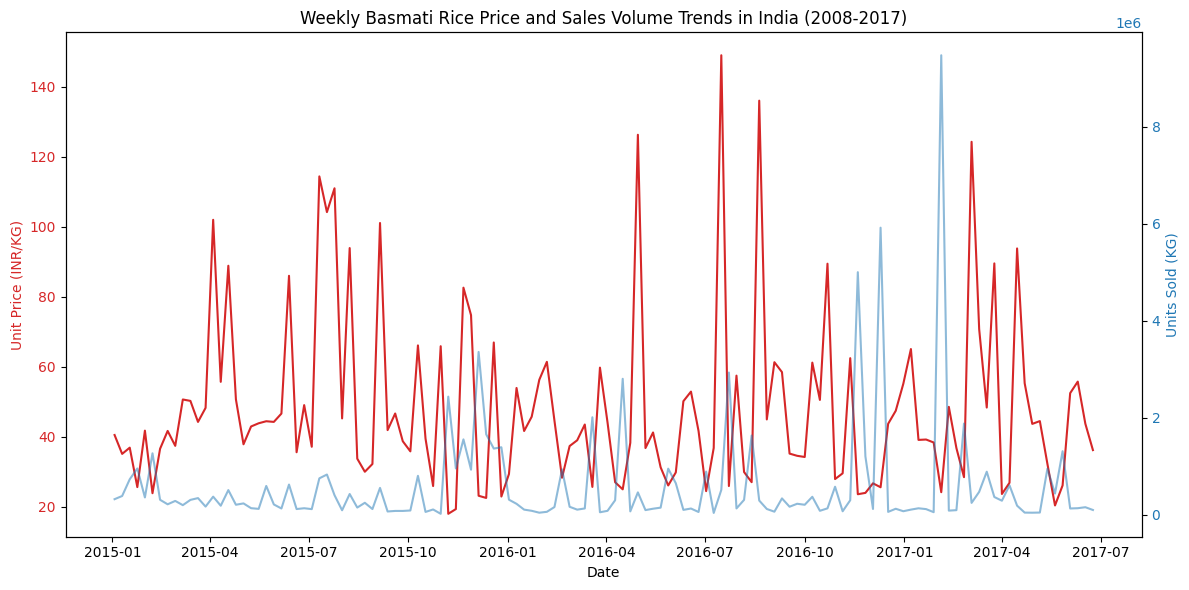

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Unit Price (INR/KG)', color=color)
ax1.plot(df['date'], df['unit_price'], color=color, label='Unit Price')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Units Sold (KG)', color=color)
ax2.plot(df['date'], df['units_sold'], color=color, alpha=0.5, label='Units Sold')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Weekly Basmati Rice Price and Sales Volume Trends in India (2008-2017)')
fig.tight_layout()
plt.show()

## Price Elasticity and Correlation

Correlation between Price and Units Sold: -0.2100


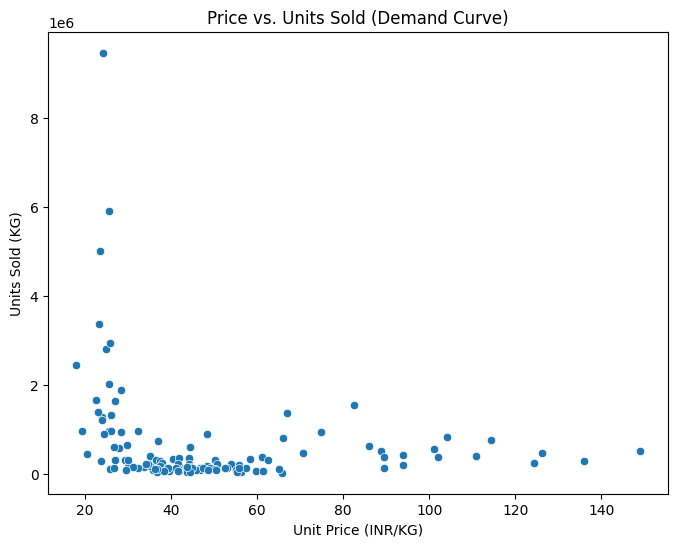

In [4]:
correlation = df['unit_price'].corr(df['units_sold'])
print(f'Correlation between Price and Units Sold: {correlation:.4f}')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='unit_price', y='units_sold')
plt.title('Price vs. Units Sold (Demand Curve)')
plt.xlabel('Unit Price (INR/KG)')
plt.ylabel('Units Sold (KG)')
plt.show()